In [1]:
using DrWatson
@quickactivate :NetworkMonitoring

update_theme!(; CairoMakie=(; px_per_unit=2.0))

## Load focal species results

In [2]:
## Load focal species results

# Use job id to vary parameters
id = parse(Int64, get(ENV, "SLURM_ARRAY_TASK_ID", "1"))
idp = lpad(id, 2, "0")

# Set directory to import results
if !(@isdefined OUTDIR)
    const OUTDIR = "focal_array" # dev(local), focal_array or efficiency
end

# Load & summarize test results
monitored_test_all = CSV.read(datadir("monitored_test.csv"), DataFrame)
monitored_test = summarize_focal(monitored_test_all; id=idp);

## Range estimation

In [3]:
# Select simulation
OUTDIR = "dev";
NREP=100
STEP=05
EXP = "$(lpad(NREP,3,"0"))-$(lpad(STEP,2,"0"))"

"100-05"

In [4]:
# Load & summarize results
function load_sim(exp)
    monitored_estimations_all = CSV.read(
    datadir(OUTDIR, "monitored_estimations-$idp-$exp.csv"), DataFrame)
    monitored_estimations = summarize_focal(monitored_estimations_all; id=idp)    
end
monitored_estimations = load_sim(EXP)
first(monitored_estimations, 3)


Row,sim,set,sp,type,sampler,layer,nbon,low,med,upp,deg
,String,String7,String7,String15,String,String15,Int64,Float64,Float64,Float64,Int64
1,01,ranges,node_55,realized,Balanced Acceptance,Over-0.2,1,0.0,0.0,0.000877193,57
2,01,ranges,node_55,realized,Balanced Acceptance,Over-0.2,6,0.0,0.0,0.0350877,57
3,01,ranges,node_55,realized,Balanced Acceptance,Over-0.2,11,0.0,0.0175439,0.0526316,57


In [5]:
# Load layers used for optimization
function load_layers(idp)
    errors = -0.2:0.05:0.2
    estimated_ranges = Dict()
    for (i, e) in enumerate(errors)
        estimated_ranges[e] = SDT.SDMLayer(
            datadir("focal_array", "layer_range_estimations-$idp.tiff"); bandnumber=i
        )
    end
    estimated_ranges    
end
estimated_ranges = load_layers(idp)


Dict{Any, Any} with 9 entries:
  0.0   => 🗺️  A 100 × 100 layer (4021 Float64 cells)
  -0.15 => 🗺️  A 100 × 100 layer (7042 Float64 cells)
  0.15  => 🗺️  A 100 × 100 layer (1303 Float64 cells)
  -0.2  => 🗺️  A 100 × 100 layer (7870 Float64 cells)
  0.2   => 🗺️  A 100 × 100 layer (750 Float64 cells)
  -0.1  => 🗺️  A 100 × 100 layer (6043 Float64 cells)
  0.1   => 🗺️  A 100 × 100 layer (2089 Float64 cells)
  0.05  => 🗺️  A 100 × 100 layer (2964 Float64 cells)
  -0.05 => 🗺️  A 100 × 100 layer (5113 Float64 cells)

In [6]:
# The set might differ, so just in case
function fix_set(estimated_ranges)
    set = ["Over-0.2", "True-0.0", "Under-0.2"]
    for (s, v) in zip(set, [-0.2, 0.0, 0.2])
        estimated_ranges[s] = estimated_ranges[v]
    end
    estimated_ranges    
end
fix_set(estimated_ranges)

Dict{Any, Any} with 12 entries:
  -0.2        => 🗺️  A 100 × 100 layer (7870 Float64 cells)
  0.0         => 🗺️  A 100 × 100 layer (4021 Float64 cells)
  0.15        => 🗺️  A 100 × 100 layer (1303 Float64 cells)
  0.2         => 🗺️  A 100 × 100 layer (750 Float64 cells)
  "Over-0.2"  => 🗺️  A 100 × 100 layer (7870 Float64 cells)
  -0.1        => 🗺️  A 100 × 100 layer (6043 Float64 cells)
  0.05        => 🗺️  A 100 × 100 layer (2964 Float64 cells)
  -0.05       => 🗺️  A 100 × 100 layer (5113 Float64 cells)
  "Under-0.2" => 🗺️  A 100 × 100 layer (750 Float64 cells)
  -0.15       => 🗺️  A 100 × 100 layer (7042 Float64 cells)
  0.1         => 🗺️  A 100 × 100 layer (2089 Float64 cells)
  "True-0.0"  => 🗺️  A 100 × 100 layer (4021 Float64 cells)

In [17]:
# Generate BON examples
set = ["Over-0.2", "True-0.0", "Under-0.2"]
begin
    Random.seed!(33)
    bons = Dict()
    for e in set
        bons[e] = BON.sample(BON.BalancedAcceptance(100), estimated_ranges[e])
    end
    bons
end

Dict{Any, Any} with 3 entries:
  "Under-0.2" => 🌐 BiodiversityObservationNetwork with 100 nodes
  "Over-0.2"  => 🌐 BiodiversityObservationNetwork with 100 nodes
  "True-0.0"  => 🌐 BiodiversityObservationNetwork with 100 nodes

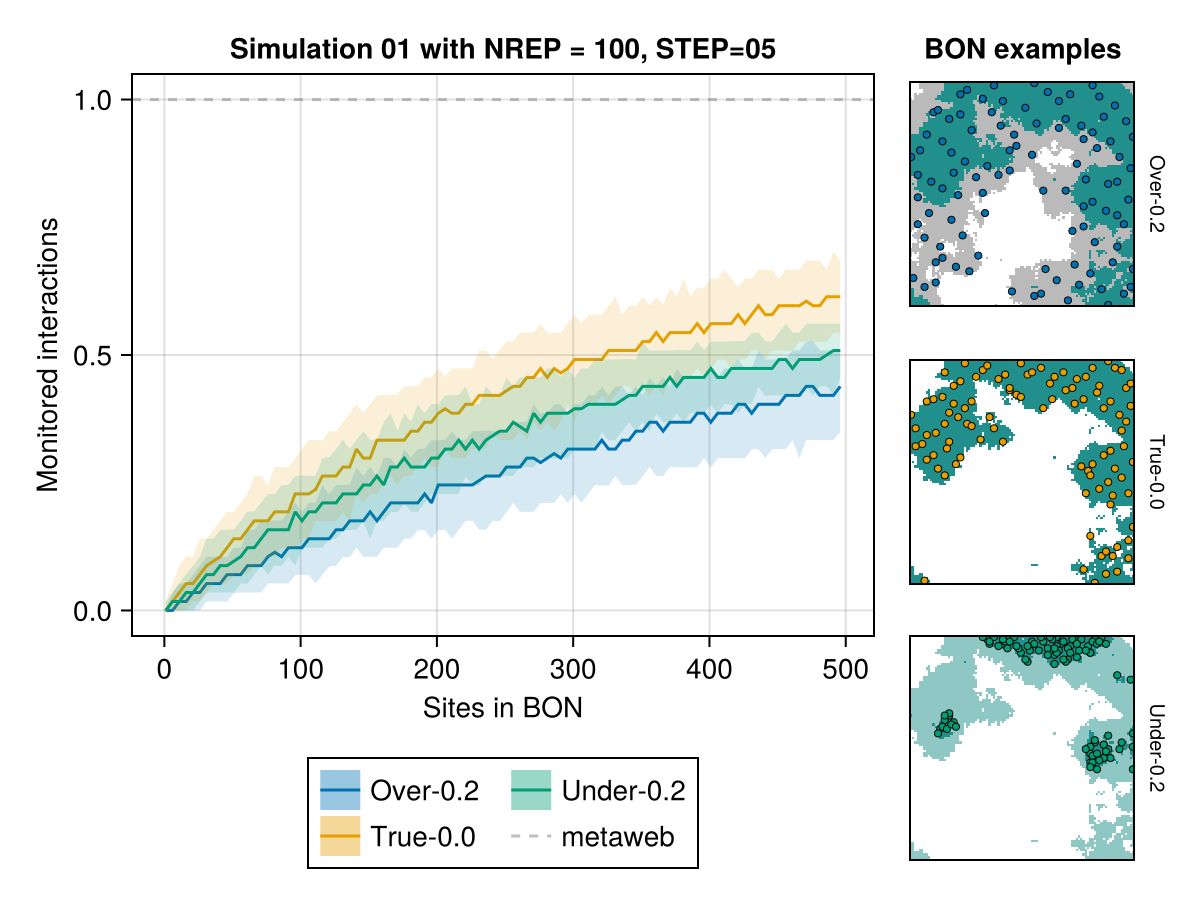

In [18]:
# Plot
function plot_sim(monitored_estimations, estimated_ranges, EXP)
    fig_estimation = let
        set = ["Over-0.2", "True-0.0", "Under-0.2"]
        var = :layer
        res = filter(var => in(set), monitored_estimations)
        vals = unique(res[:, var])

        range_over = estimated_ranges[set[1]]
        range_true = estimated_ranges[set[2]]
        range_under = estimated_ranges[set[3]]

        if !(@isdefined colours)
            colours = Dict()
        end
        for (i, s) in enumerate(set)
            colours[s] = Makie.wong_colors()[i]
        end

        # Create figure
        fig = Figure()
        # Create layouts
        ga = GridLayout(fig[:, 1:3])
        gb = GridLayout(fig[:, end + 1])
        # Create axes
        ax = Axis(
            ga[1, 1];
            xlabel="Sites in BON",
            ylabel="Monitored interactions",
            xticks=0:100:500,
        )
        ax1 = Axis(
            gb[1, 1]; aspect=1, yaxisposition=:right, ylabelrotation=1.5pi, ylabelsize=10
        )
        ax2 = Axis(
            gb[2, 1]; aspect=1, yaxisposition=:right, ylabelrotation=1.5pi, ylabelsize=10
        )
        ax3 = Axis(
            gb[3, 1]; aspect=1, yaxisposition=:right, ylabelrotation=1.5pi, ylabelsize=10
        )
        # Remove decorations for heatmaps
        hidedecorations!(ax1; label=false)
        hidedecorations!(ax2; label=false)
        hidedecorations!(ax3; label=false)

        # Sampling results
        for v in vals
            b = filter(var => ==(v), res)
            band!(ax, b.nbon, b.low, b.upp; alpha=0.4, color=colours[v], label=v)
            lines!(ax, b.nbon, b.med; label=v)
        end
        hlines!(ax, [1.0]; linestyle=:dash, alpha=0.5, color=:grey, label="metaweb")
        Legend(ga[2, 1], ax; orientation=:horizontal, merge=true, nbanks=2)
        # Heatmaps & BON example
        heatmap!(ax1, range_over; colormap=:greys, alpha=0.5)
        heatmap!(ax1, range_true; colormap=:viridis)
        heatmap!(ax2, range_true; colormap=:viridis)
        heatmap!(ax3, range_true; colormap=:viridis, alpha=0.5)
        heatmap!(ax3, range_under; colormap=:viridis)
        for (a, v) in zip([ax1, ax2, ax3], vals)
            scatter!(a, coordinates(bons[v]); markersize=5, strokewidth=0.5, color=colours[v])
            a.ylabel = v
        end

        # Subpanel labels
        nrep,step = split(EXP, "-")
        Label(ga[1, :, Top()], "Simulation $idp with NREP = $nrep, STEP=$step"; padding=(0, 0, 5, 0), font=:bold)
        Label(gb[1, :, Top()], "BON examples"; padding=(0, 0, 5, 0), font=:bold)
        # Show figure
        save(plotsdir("focal_ranges-$EXP.png"), fig)
        fig
    end
end
plot_sim(monitored_estimations, estimated_ranges, EXP)

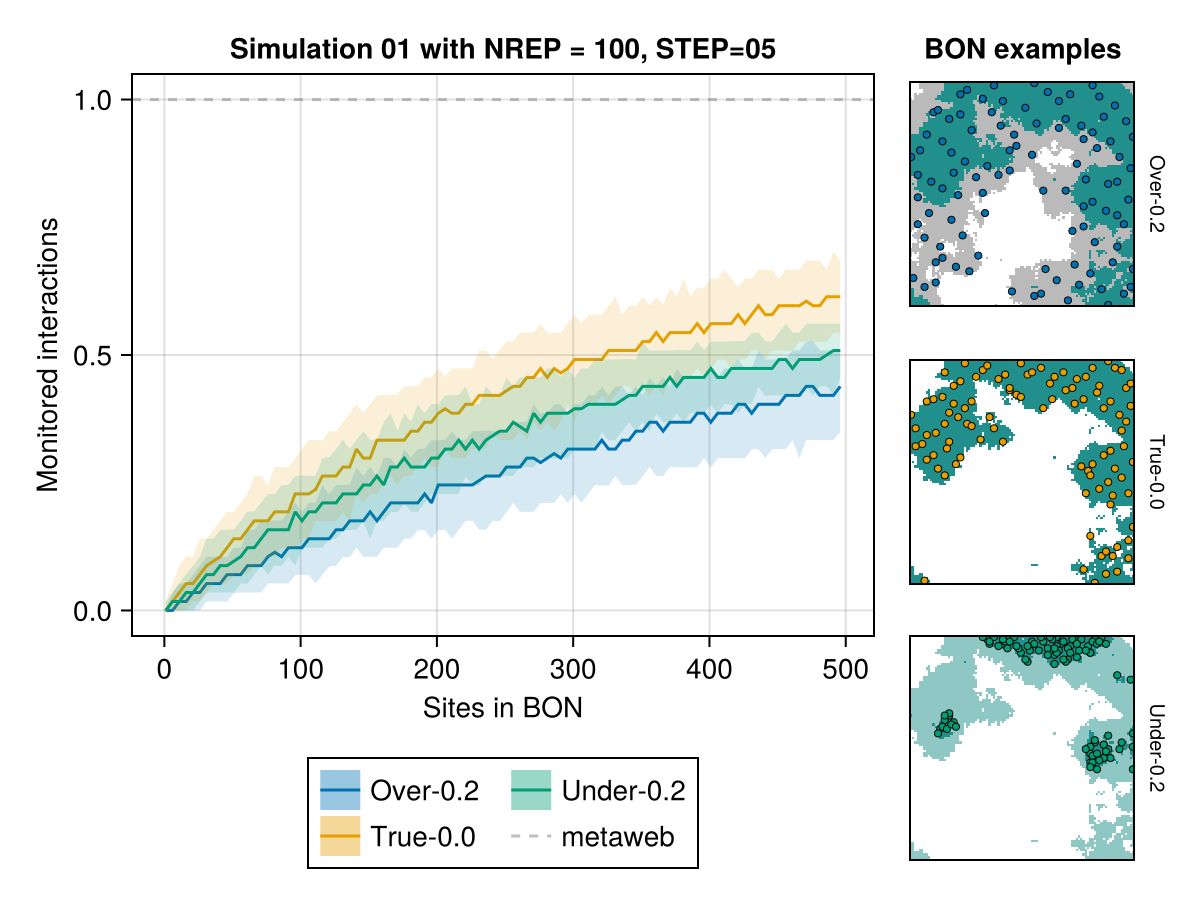

In [19]:
function load_and_plot(EXP, idp)
    monitored_estimations = load_sim(EXP)
    plot_sim(monitored_estimations, estimated_ranges, EXP)
end
load_and_plot(EXP, idp)

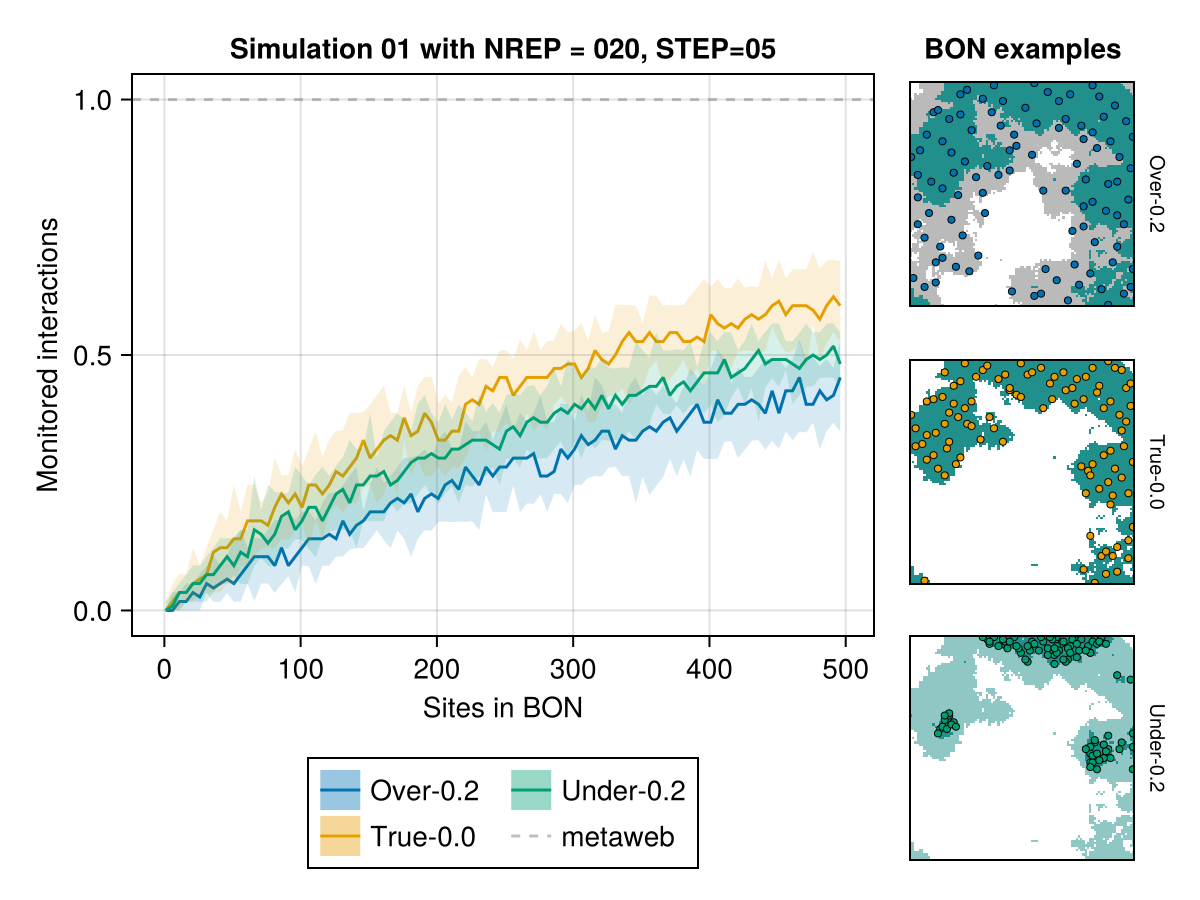

In [20]:
load_and_plot("020-05", "01")

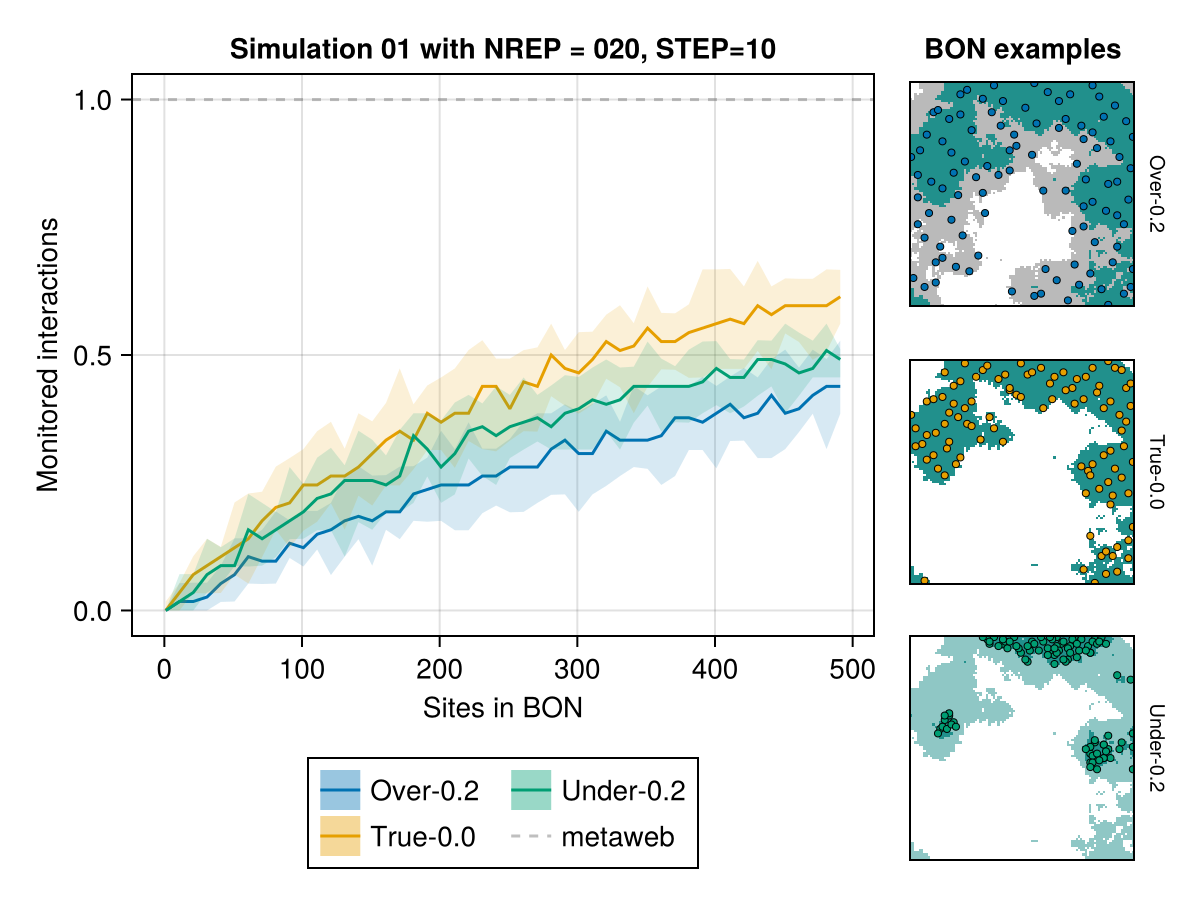

In [21]:
load_and_plot("020-10", "01")

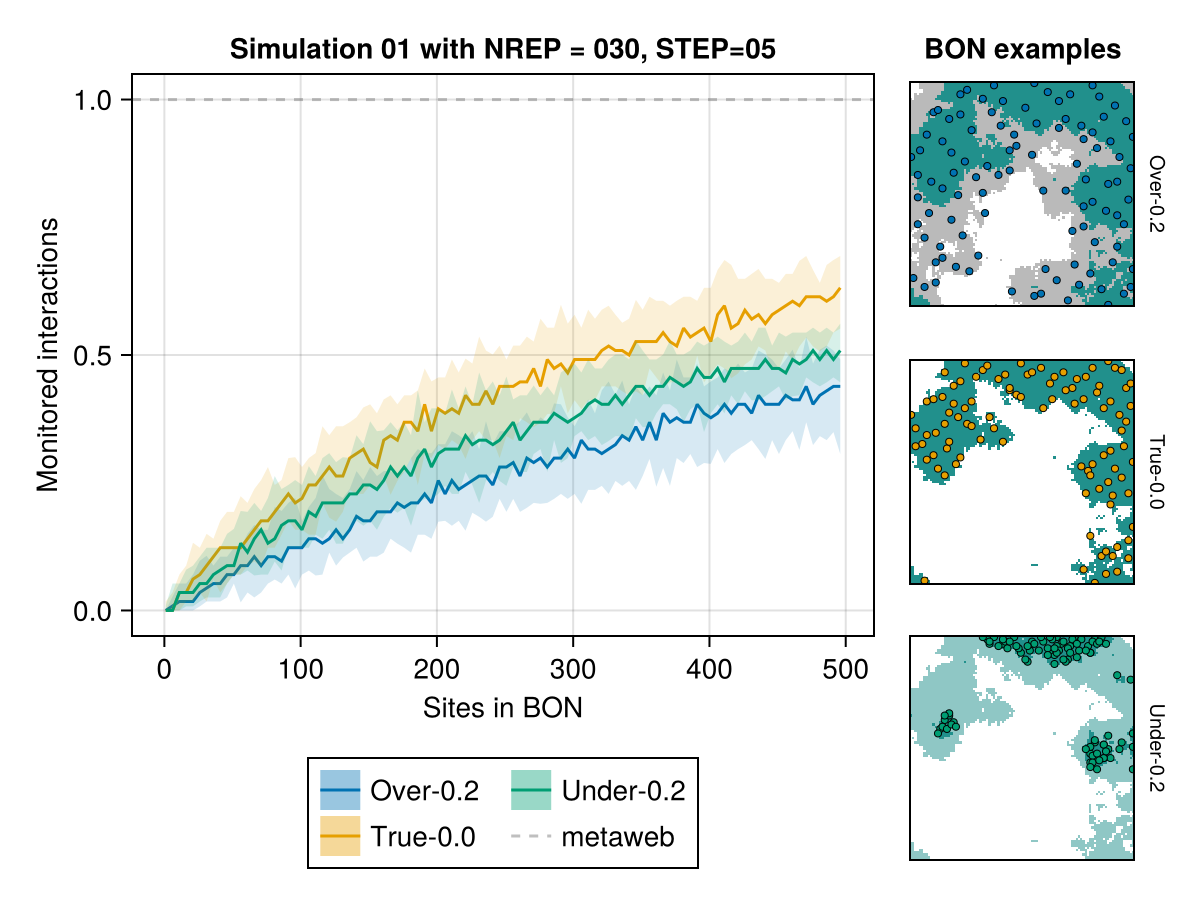

In [22]:
load_and_plot("030-05", "01")

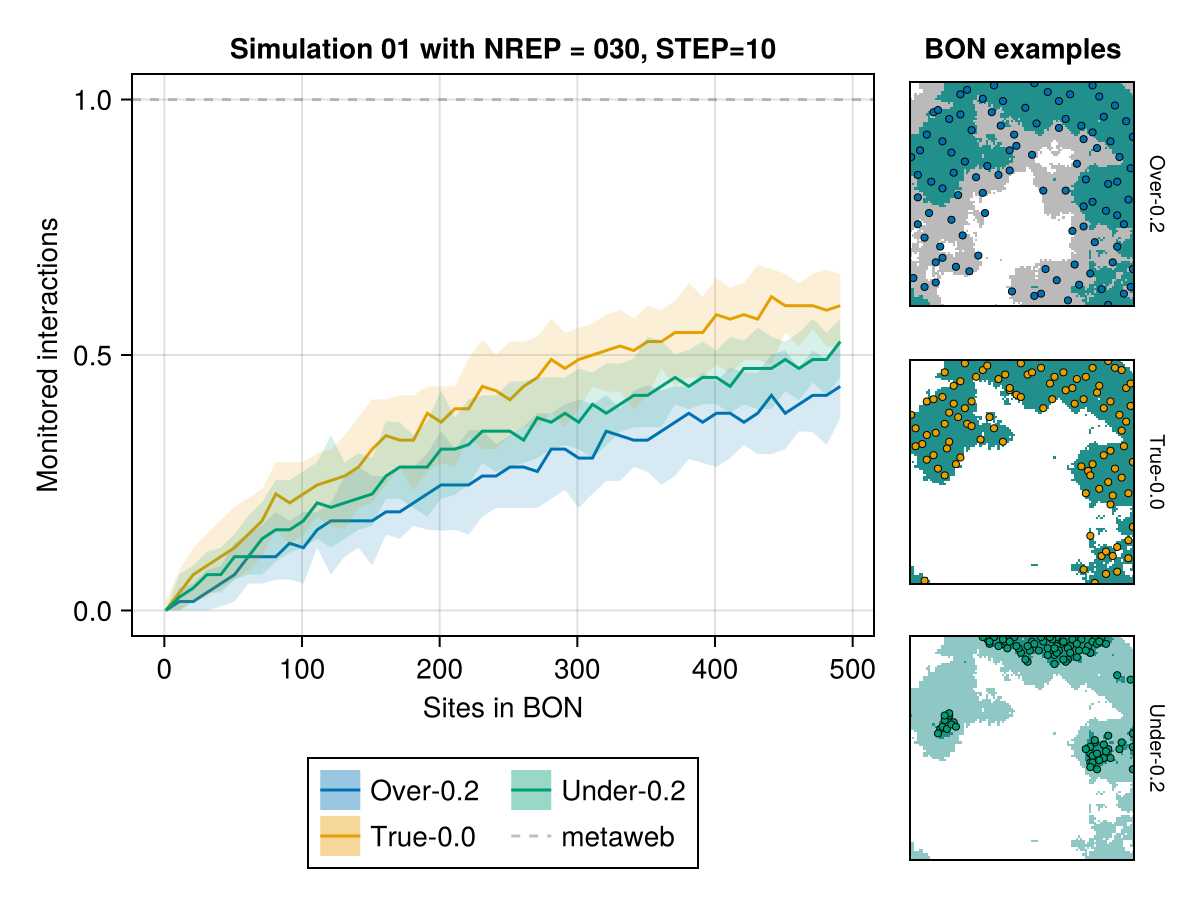

In [23]:
load_and_plot("030-10", "01")

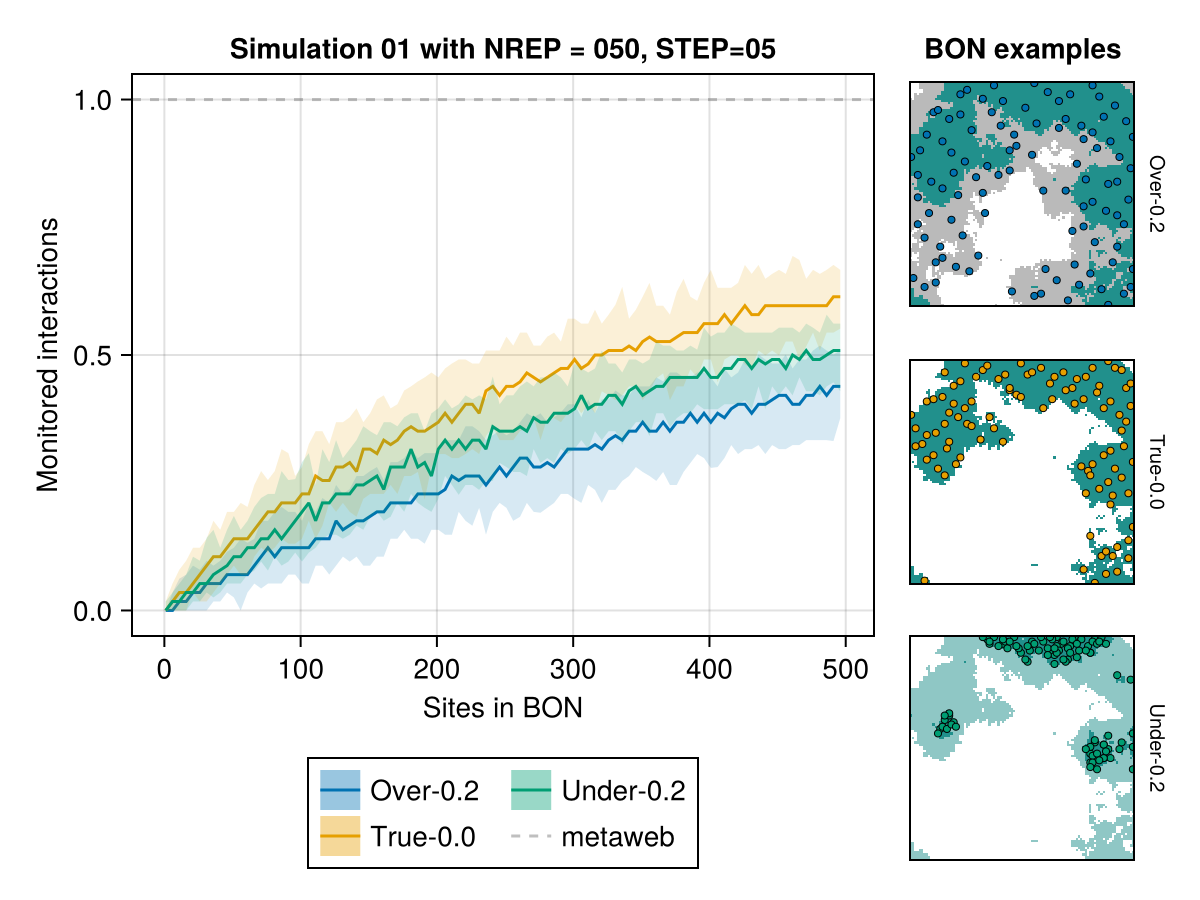

In [24]:
load_and_plot("050-05", "01")

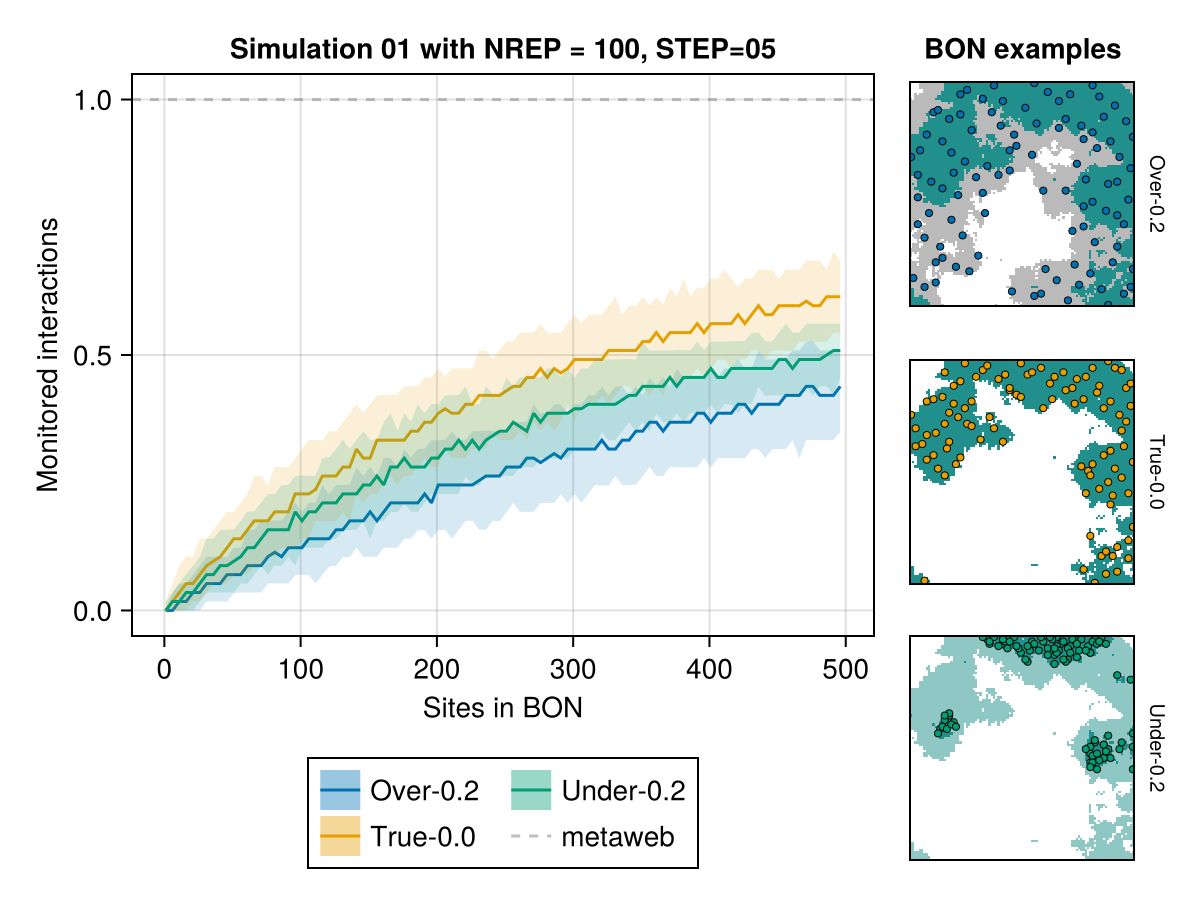

In [25]:
load_and_plot("100-05", "01")